# Autonomous Abdominal-CT Segmentation — Tests & Dice Scores

Every segmentation experiment we ran, with the **actual measured Dice** and what each one tells us.
All numbers are real results from the scripts noted in each section (on held-out CT). Bars are drawn
from the embedded results so the notebook renders without re-running hours of SAM3 inference.

**Backbone:** SAM3 (`facebook/sam3`). **Prompt modes:** `gtbox` = GT-derived box (*semi-oracle*,
needs a label), `fullbox` = whole-image box (autonomous), `concept "<text>"` = text prompt only
(*fully autonomous*, no label). Dice is vs ground-truth masks.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

def barh(d, title, ceiling=None, note=None):
    labels = list(d.keys()); vals = list(d.values())
    colors = ['#c0392b' if v < 0.5 else ('#1e7a3c' if v >= 0.9 else '#e08e0b') for v in vals]
    fig, ax = plt.subplots(figsize=(8, 0.55*len(labels)+1))
    ax.barh(labels, vals, color=colors); ax.set_xlim(0, 1); ax.invert_yaxis()
    for i, v in enumerate(vals): ax.text(v+0.01, i, f'{v:.3f}', va='center', fontsize=9)
    if ceiling is not None: ax.axvline(ceiling, ls='--', c='gray'); ax.text(ceiling, -0.6, f'ceiling {ceiling:.3f}', fontsize=8)
    ax.set_xlabel('Dice'); ax.set_title(title, fontweight='bold')
    if note: ax.text(0, len(labels)+0.1, note, fontsize=8, style='italic', color='#555')
    plt.tight_layout(); plt.show()
print('ready')

ready


## 1. Can a text prompt replace the ground-truth box? — Liver

The core question: our fine-tuned SAM3 is box-prompted, which needs a label. Does **concept
prompting** (`text="liver"`, no box) work on an unlabeled scan? Test case: held-out **FLARE23_0217**.
Script: `src/scripts/exp_sam3_prompt_bakeoff.py`.

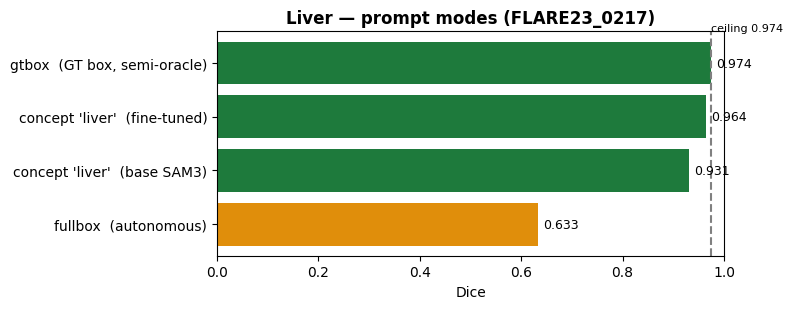

In [2]:
liver = {
    "gtbox  (GT box, semi-oracle)":      0.974,   # ceiling — needs a label
    "concept 'liver'  (fine-tuned)":     0.964,   # AUTONOMOUS — no label
    "concept 'liver'  (base SAM3)":      0.931,   # autonomous, no fine-tuning at all
    "fullbox  (autonomous)":             0.633,
}
barh(liver, "Liver — prompt modes (FLARE23_0217)", ceiling=0.974)

**Finding.** The autonomous concept prompt (**0.964**) is within **0.010** of the semi-oracle
ceiling (0.974) — even *base* SAM3 hits 0.931. For a large, high-contrast organ, a label buys almost
nothing. This is the breakthrough: **organs can be segmented on unlabeled CT.**

## 2. The harder structures — Pancreas (organ) and its Tumor

Liver is the easy case. Pancreas is small, low-contrast, variable. And tumors are the real test.
Test case: **pancreas_001**. Script: `src/scripts/exp_sam3_bakeoff2.py`.

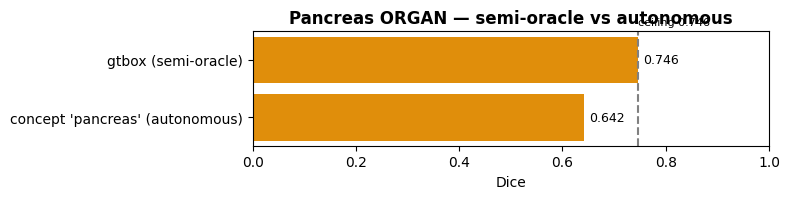

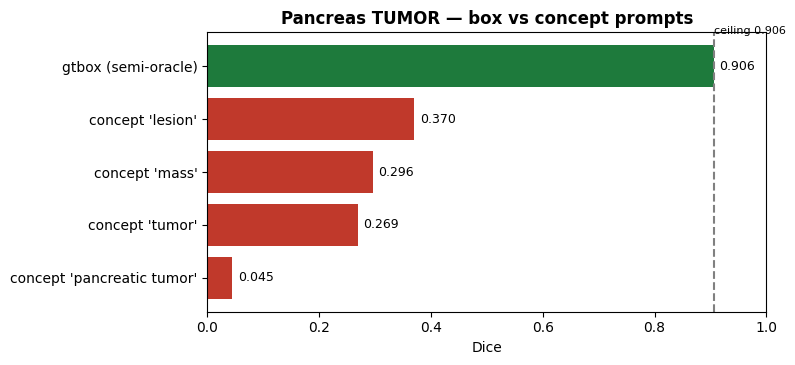

In [3]:
panc_organ = {
    "gtbox (semi-oracle)":            0.746,
    "concept 'pancreas' (autonomous)": 0.642,
}
panc_tumor = {
    "gtbox (semi-oracle)":       0.906,   # box-prompted ceiling
    "concept 'lesion'":          0.370,
    "concept 'mass'":            0.296,
    "concept 'tumor'":           0.269,
    "concept 'pancreatic tumor'":0.045,
}
barh(panc_organ, "Pancreas ORGAN — semi-oracle vs autonomous", ceiling=0.746)
barh(panc_tumor, "Pancreas TUMOR — box vs concept prompts", ceiling=0.906)

**Finding.** Pancreas organ concept prompting is **usable but weaker (0.642 vs 0.746)** — a
~0.10 gap, unlike liver's 0.01. And **`"tumor"` concept prompting collapses (0.05–0.37 vs a 0.906
box ceiling)** — SAM3's pretrained vocabulary doesn't know medical tumors. Tumors need training.

## 3. The generic tumor model — training fixes tumors

Fix for the tumor gap: fine-tune SAM3 with `text="tumor"` (no box) on **pooled** tumor masks across
datasets, so it works autonomously at inference. Each added tumor type lifts it.
Scripts: `train_tumor_generic.py` / `_v2.py` / `_v3.py`.

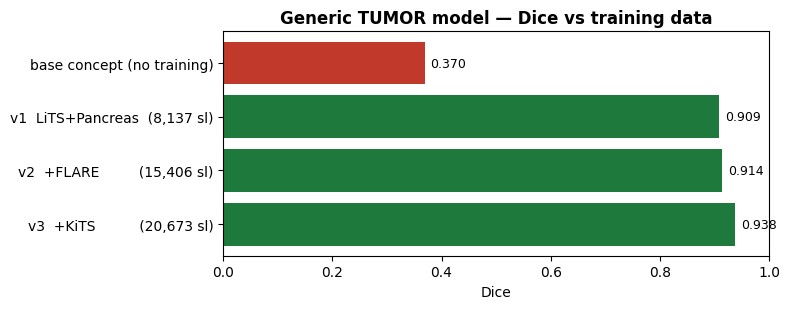

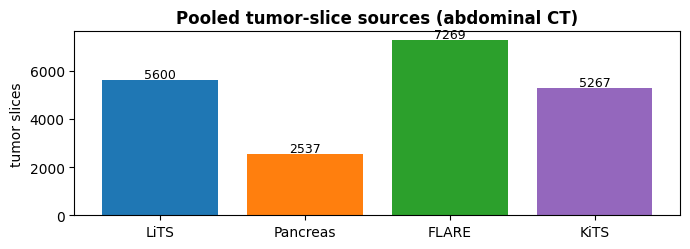

In [4]:
# autonomous (text='tumor', no box) validation Dice, by training pool
tumor_progress = {
    "base concept (no training)":              0.370,
    "v1  LiTS+Pancreas  (8,137 sl)":           0.909,
    "v2  +FLARE         (15,406 sl)":          0.9145,
    "v3  +KiTS          (20,673 sl)":          0.9384,   # final (converged; stopped at plateau)
}
barh(tumor_progress, "Generic TUMOR model — Dice vs training data", ceiling=None)

# training pool composition per version
pool = {"LiTS": 5600, "Pancreas": 2537, "FLARE": 7269, "KiTS": 5267}
fig, ax = plt.subplots(figsize=(7,2.6))
ax.bar(pool.keys(), pool.values(), color=['#1f77b4','#ff7f0e','#2ca02c','#9467bd'])
for i,(k,v) in enumerate(pool.items()): ax.text(i, v+80, str(v), ha='center', fontsize=9)
ax.set_ylabel('tumor slices'); ax.set_title('Pooled tumor-slice sources (abdominal CT)', fontweight='bold')
plt.tight_layout(); plt.show()

**Finding.** Autonomous tumor Dice climbs **0.37 → 0.909 → 0.9145 → 0.9384** as we pool more
tumor types (liver, pancreas, then FLARE organs, then kidney via KiTS). **Cross-dataset medical
training is what makes autonomous tumor segmentation work** — and coverage keeps improving it.

## 4. The generalization caveat — does it transfer to UNSEEN tumor types?

Critical honesty check: the v1 model (trained on **liver+pancreas only**) applied to a *different*
dataset's tumors — **FLARE**, which includes **kidney** tumors it never saw. Script: `flare23_predict.py`.

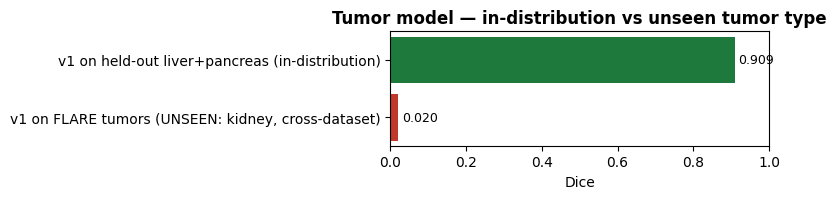

In [5]:
crossds = {
    "v1 on held-out liver+pancreas (in-distribution)": 0.909,
    "v1 on FLARE tumors (UNSEEN: kidney, cross-dataset)": 0.020,
}
barh(crossds, "Tumor model — in-distribution vs unseen tumor type")

**Finding.** The 0.909 model scored **0.02** on unseen FLARE (kidney) tumors — it does **not**
transfer to tumor types absent from training. This is *why* we expand the pool: adding FLARE and KiTS
is what lifted the model (§3). The correct claim is **"reliable within trained tumor types,"** not
"universally autonomous."  

## 5. Per-organ segmentation (semi-oracle) — where the KG gets its numbers

Organ masks on 9 held-out FLARE cases, **gtbox (semi-oracle)** — this is the upper bound per organ,
and what the *predicted* KG uses when a label box is available. Script: `flare23_predict.py`.

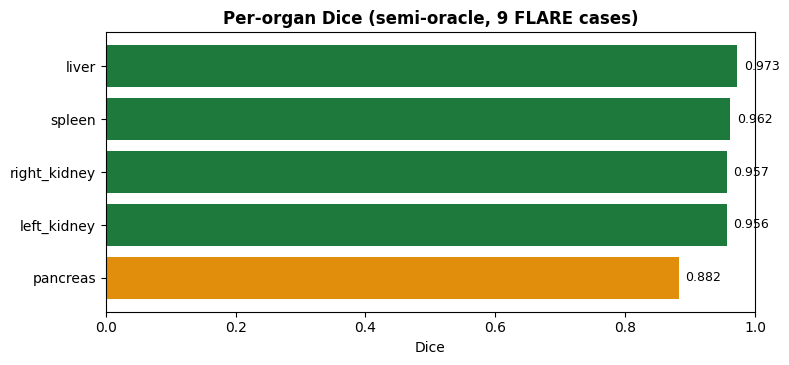

In [6]:
organ_semioracle = {   # mean Dice over 9 FLARE cases, GT-box prompted
    "liver":        0.9727,
    "spleen":       0.9621,
    "right_kidney": 0.9565,
    "left_kidney":  0.9564,
    "pancreas":     0.8825,
}
barh(organ_semioracle, "Per-organ Dice (semi-oracle, 9 FLARE cases)")

**Finding.** Semi-oracle organ Dice is strong (0.95–0.97) except **pancreas (0.88)** — the
hardest organ, consistent with §2. Note: these are *semi-oracle*; the **autonomous** per-organ sweep
(concept prompts for all 13 organs) is the next measurement, to target the fine-tune where it's needed.

## 6. Context — earlier LiTS tumor result (SAM1 / AUSAM)

Before the SAM3 pivot, the LiTS tumor model used SAM1 + DBSCAN point prompts (semi-oracle).
Reported for continuity. Script: `eval_lits_ausam.py`.

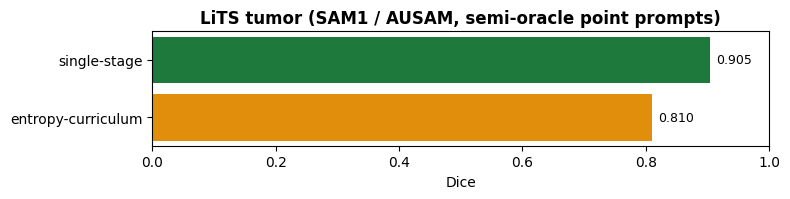

In [7]:
lits_sam1 = {"single-stage": 0.905, "entropy-curriculum": 0.810}
barh(lits_sam1, "LiTS tumor (SAM1 / AUSAM, semi-oracle point prompts)")

## 7. Summary

| Test | Best autonomous | Semi-oracle ceiling | Takeaway |
|---|---|---|---|
| Liver organ | **0.964** (concept) | 0.974 | autonomous ≈ semi-oracle |
| Pancreas organ | 0.642 (concept) | 0.746 | usable, weaker — fine-tune target |
| Other organs (spleen/kidney) | *TBD* | 0.95–0.96 | likely fine; measure autonomously |
| Tumor (generic model) | **0.938** (text, v3) | 0.906 (per-organ box) | training beats the per-organ box |
| Tumor, unseen type (cross-dataset) | 0.020 | — | must include the type in training |

**Overall.** Foundation-model concept prompting is excellent for large organs and essentially free of
manual localization; small organs (pancreas) and tumors need medical fine-tuning; and tumor coverage
must be grown deliberately (LiTS→Pancreas→FLARE→KiTS: 0.909→0.938). Combined, autonomous organs + the
trained tumor model produce organ masks, tumor masks, and the imaging KG for new unlabeled CT.

## 8. The KG-in-training ablation — baseline vs KG *(live demo)*

**What this section shows.** Each model is trained **twice** — a plain **baseline** and a **`--kg`** version
that adds the KG anatomical-plausibility loss — so we can measure what the knowledge graph contributes *to
learning*. The cells below **load the current results files**, so they fill in automatically as the runs
finish (re-run a cell if a file was still training when you opened this).

**How to read it (important for expectations):**
- These are **slice-level, patient-split** Dice — *optimistic* by construction (the model is only scored on
  slices that contain the organ). The honest deployment number is the **patient-level / full-volume** pass,
  which is a separate step and will be **lower**, most of all for pancreas and tumor.
- The **organ** ablation is epoch-matched at convergence — trustworthy. The **tumor** ablation is a
  **directional first look** (KG@6 vs a 14-epoch baseline, not epoch-matched); a small negative may be the
  epoch gap, not the KG. The cell prints a ⚠️ when that's the case.
- Expect the KG's effect to show up in **pancreas** and, later, in the **full-volume / false-positive** regime
  — not in the blended slice-level average.

In [8]:
import os, json, glob
import numpy as np
import matplotlib.pyplot as plt

R = next((p for p in ["../../results", os.path.expanduser("~/Desktop/SWOG/results"),
                      "/home/ud3d4/Desktop/SWOG/results"] if os.path.isdir(p)), "results")
def load(name):
    p = os.path.join(R, name)
    return json.load(open(p)) if os.path.exists(p) else None
print("results dir:", R)

results dir: ../../results


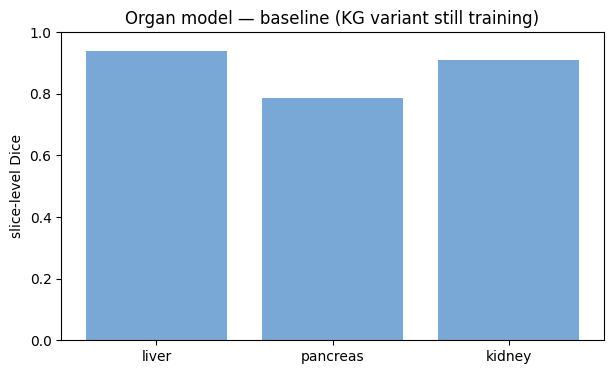

baseline per-organ: {'liver': 0.9408, 'pancreas': 0.787, 'kidney': 0.9091}
KG variant: TRAINING — re-run this cell once organ_generic_kg.json exists.


In [9]:
# --- ORGAN: baseline vs KG (slice-level, held-out patient test) ---
ob, ok = load("organ_generic.json"), load("organ_generic_kg.json")
if ob is None:
    print("organ baseline not found yet.")
else:
    organs = list(ob["per_organ"]); base = [ob["per_organ"][o] for o in organs]
    if ok:
        kg = [ok["per_organ"].get(o, np.nan) for o in organs]
        x = np.arange(len(organs)); w = 0.38
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.bar(x - w/2, base, w, label="baseline", color="#7aa8d6")
        ax.bar(x + w/2, kg, w, label="+ KG-in-training", color="#2f5c8f")
        for i, (b, k) in enumerate(zip(base, kg)):
            ax.text(i, max(b, k) + 0.012, f"{k-b:+.3f}", ha="center", fontsize=9)
        ax.set_xticks(x); ax.set_xticklabels(organs); ax.set_ylim(0, 1)
        ax.set_ylabel("slice-level Dice"); ax.set_title("Organ model — baseline vs KG (Δ = KG effect)")
        ax.legend(); plt.show()
        print("per-organ Δ (KG - baseline):", {o: round(k-b, 4) for o, b, k in zip(organs, base, kg)})
    else:
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.bar(organs, base, color="#7aa8d6"); ax.set_ylim(0, 1); ax.set_ylabel("slice-level Dice")
        ax.set_title("Organ model — baseline (KG variant still training)"); plt.show()
        print("baseline per-organ:", ob["per_organ"])
        print("KG variant: TRAINING — re-run this cell once organ_generic_kg.json exists.")

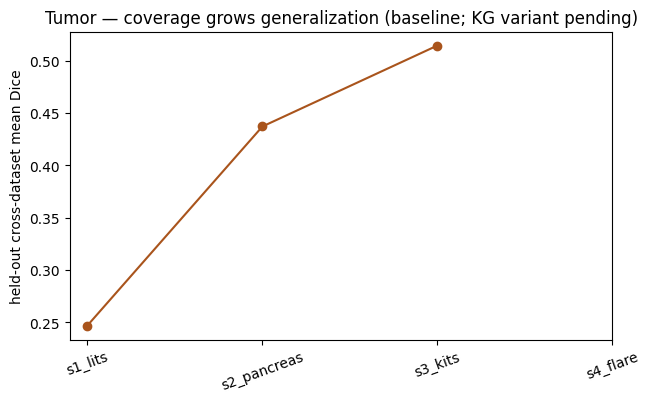

tumor final per-dataset (baseline): {'pancreas': 0.6476, 'lits': 0.6712, 'flare': 0.7077, 'kits': 0.7885}
KG variant: pending step 4 — re-run once tumor_incremental_kg.json exists.


In [10]:
# --- TUMOR: baseline vs KG (final all-4-dataset stage; directional if epochs differ) ---
tb, tk = load("tumor_incremental.json"), load("tumor_incremental_kg.json")
if tb is None:
    print("tumor baseline not found.")
else:
    fb = tb["stages"][-1]["per_dataset_test"]
    if tk:
        fk = tk["stages"][-1]["per_dataset_test"]
        if tb.get("epochs") != tk.get("epochs"):
            print(f"WARNING  DIRECTIONAL: baseline={tb.get('epochs')} ep vs KG={tk.get('epochs')} ep - not epoch-matched.")
        dsets = sorted(set(fb) & set(fk)); base = [fb[d] for d in dsets]; kg = [fk[d] for d in dsets]
        x = np.arange(len(dsets)); w = 0.38
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.bar(x - w/2, base, w, label="baseline", color="#e0a97a")
        ax.bar(x + w/2, kg, w, label="+ KG", color="#a9541c")
        for i, (b, k) in enumerate(zip(base, kg)):
            ax.text(i, max(b, k) + 0.012, f"{k-b:+.3f}", ha="center", fontsize=9)
        ax.set_xticks(x); ax.set_xticklabels(dsets); ax.set_ylim(0, 1)
        ax.set_ylabel("slice-level tumor Dice"); ax.set_title("Tumor model — baseline vs KG (final, all 4 datasets)")
        ax.legend(); plt.show()
    else:
        stages = [s["name"] for s in tb["stages"]]
        held = [np.mean(list(s["cross_dataset_heldout"].values())) if s["cross_dataset_heldout"] else np.nan
                for s in tb["stages"]]
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(range(len(stages)), held, "o-", color="#a9541c")
        ax.set_xticks(range(len(stages))); ax.set_xticklabels(stages, rotation=20)
        ax.set_ylabel("held-out cross-dataset mean Dice")
        ax.set_title("Tumor — coverage grows generalization (baseline; KG variant pending)"); plt.show()
        print("tumor final per-dataset (baseline):", fb)
        print("KG variant: pending step 4 — re-run once tumor_incremental_kg.json exists.")

In [11]:
# --- ablation summary + confusion matrices (produced by the patient-level pass) ---
summ = load("kg_ablation_summary.json")
if summ:
    print("kg_ablation_summary.json:\n", json.dumps(summ, indent=1))
from IPython.display import Image, display
imgs = sorted(glob.glob(os.path.join(R, "confusion_*_*.png")))
if imgs:
    for p in imgs:
        print(os.path.basename(p)); display(Image(p))
else:
    print("Confusion matrices: pending the patient-level / full-volume pass (confusion_eval.py).")

Confusion matrices: pending the patient-level / full-volume pass (confusion_eval.py).


### What to expect next
This section is **layer 1** (does the KG help the segmenter *learn*). The real payoff is the **end-to-end**
run — the **patient-level 3-D Dice**, the **confusion matrices** above, and the **system-level OAKG test**
(GT-free validation, retrieval on *predicted* phenotypes, cohort growth) on the pipeline's own output. Those
land after the full-volume pass; this notebook will render them here as they arrive.